In [ ]:
# Package imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown

# Data download
file_id = "1lMtcGAhRBh0GAWBs68vHonseUb3bMzdT"
data_url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(data_url, "data.csv", quiet=False)

# Data import
df = pd.read_csv("data.csv")

Downloading...
From: https://drive.google.com/uc?id=1lMtcGAhRBh0GAWBs68vHonseUb3bMzdT
To: /content/data.csv
100%|██████████| 341k/341k [00:00<00:00, 47.3MB/s]


#**Team Member 1: Yuki Li**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving CHAPA_applications_concat_unclean.csv to CHAPA_applications_concat_unclean.csv


In [ ]:
import pandas as pd

df = pd.read_csv("CHAPA_applications_concat_unclean.csv")
df.head()


,Unnamed: 0,ID Number,Submission Date,Application Property,Source,Age,Race/Ethnicity,Disability,Current Residence,HH Size,Dependents,HH Type,HH Income,HH Assets,FTHB Class?
0,0,150733,2022-02-08 00:00:00.000,8 Ciderpress Way,NaN,65,white,NaN,somerville,1,NaN,NaN,37934,NaN,NaN
1,1,439181,2022-02-08 00:00:00.000,8 Ciderpress Way,NaN,59,hispanic,NaN,westford,2,NaN,NaN,61000,NaN,NaN
2,2,697399,2022-02-08 00:00:00.000,8 Ciderpress Way,NaN,NaN,black/afr am,NaN,malden,2,NaN,NaN,31275,346000,NaN
3,3,191565,2022-02-08 00:00:00.000,8 Ciderpress Way,NaN,NaN,white,NaN,haverhill,1,NaN,NaN,20299,NaN,NaN
4,4,226436,2022-02-08 00:00:00.000,8 Ciderpress Way,NaN,60,white,NaN,"Nashua,NH",1,NaN,NaN,41000,NaN,NaN


In [ ]:
df['Submission Date'] = pd.to_datetime(df['Submission Date'], errors='coerce')


In [ ]:
df['Submission Date'].dtype

dtype('<M8[ns]')

In [ ]:
df['Submission Date'].min(), df['Submission Date'].max()


(Timestamp('2021-06-15 00:00:00'), Timestamp('2025-05-13 08:29:55'))

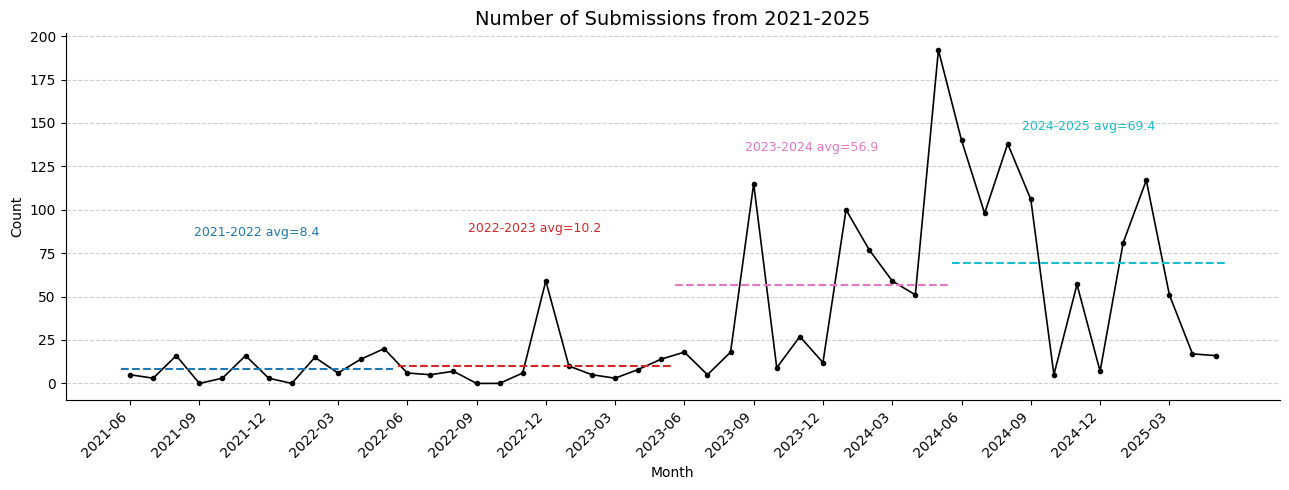

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df['Submission Date'] = pd.to_datetime(df['Submission Date'], errors='coerce')
df = df.dropna(subset=['Submission Date']).copy()

monthly = (
    df.set_index('Submission Date')
      .resample('MS')   # Month Start frequency
      .size()
      .rename('count')
      .to_frame()
      .reset_index()
      .rename(columns={'Submission Date':'date'})
)

def jm_year(ts):
    start = ts.year if ts.month >= 6 else ts.year - 1
    return f"{start}-{start+1}"

monthly['jm_year'] = monthly['date'].apply(jm_year)
monthly['xpos'] = np.arange(len(monthly))

plt.figure(figsize=(13,5))
ax = plt.gca()

ax.plot(monthly['xpos'], monthly['count'],
        color='black', linewidth=1.2, marker='o', markersize=3)

ax.set_title('Number of Submissions from 2021-2025', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Count')

xtick_idx = monthly.index[::3]
ax.set_xticks(monthly.loc[xtick_idx, 'xpos'])
ax.set_xticklabels(monthly.loc[xtick_idx, 'date'].dt.strftime('%Y-%m'),
                   rotation=45, ha='right')

years = list(monthly['jm_year'].unique())
colors = cm.tab10(np.linspace(0, 1, len(years)))  # matplotlib tab10

for color, (year, g) in zip(colors, monthly.groupby('jm_year')):
    y_avg = g['count'].mean()
    xmin = g['xpos'].min() - 0.4
    xmax = g['xpos'].max() + 0.4
    ax.hlines(y=y_avg, xmin=xmin, xmax=xmax,
              colors=color, linestyles='--', linewidth=1.5)

    ax.text((xmin + xmax)/2, y_avg + 75, f'{year} avg={y_avg:.1f}',
        color=color, va='bottom', ha='center', fontsize=9, fontweight='medium')

ax.grid(axis='y', linestyle='--', alpha=0.6)
for s in ['top','right']:
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.show()


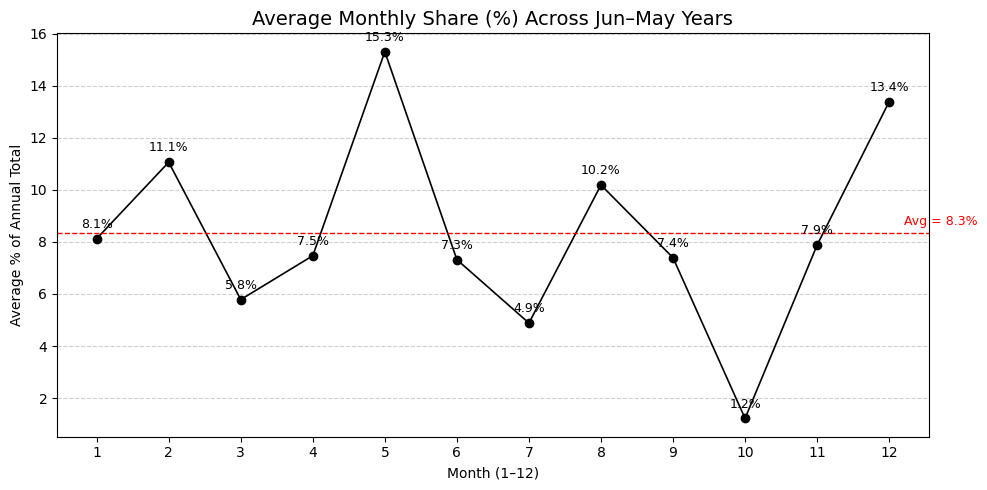

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

avg_share = monthly.groupby('month')['monthly_share'].mean()

plt.figure(figsize=(10,5))

plt.plot(avg_share.index, avg_share.values, marker='o',
         color='black', linewidth=1.2)

for x, y in zip(avg_share.index, avg_share.values):
    plt.text(x, y + 0.3, f"{y:.1f}%", ha='center', va='bottom', fontsize=9)

overall_avg = avg_share.mean()
plt.axhline(overall_avg, color='red', linestyle='--', linewidth=1)
plt.text(12.2, overall_avg + 0.2, f'Avg = {overall_avg:.1f}%', color='red',
         va='bottom', fontsize=9)

plt.title('Average Monthly Share (%) Across Jun–May Years', fontsize=14)
plt.xlabel('Month (1–12)')
plt.ylabel('Average % of Annual Total')
plt.xticks(np.arange(1,13))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
df['Age'].isna().mean()

np.float64(0.06436781609195402)

In [ ]:
df['Age'].isna().sum()


np.int64(113)

In [ ]:
df['Age'].dtype

dtype('O')

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

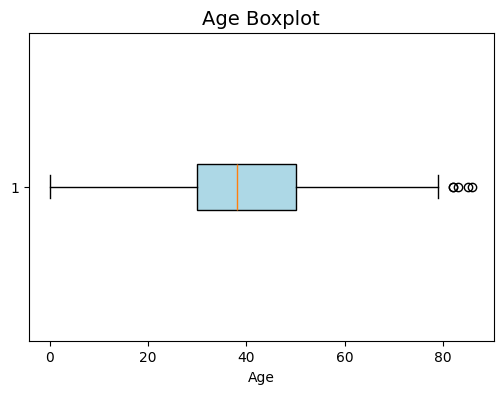

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Age'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Age Boxplot', fontsize=14)
plt.xlabel('Age')
plt.show()


In [ ]:
df_18plus = df[df['Age'] >= 18].copy()


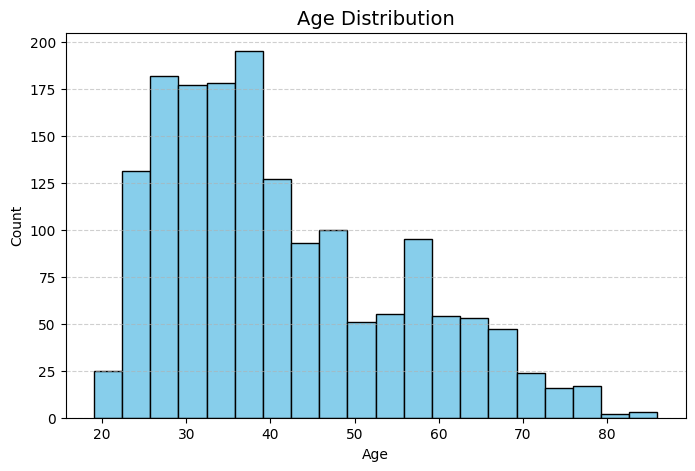

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_18plus['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [ ]:
df['HH Assets'].dtype

dtype('O')

In [ ]:
df['HH Assets'] = (
    df['HH Assets']
    .astype(str)
    .str.replace('[\$,]', '', regex=True)
    .str.replace('k', '000', regex=False)
    .str.replace('K', '000', regex=False)
    .astype(float)
)
df['HH Assets'].dtype


<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2211572204.py:4: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True)


dtype('float64')

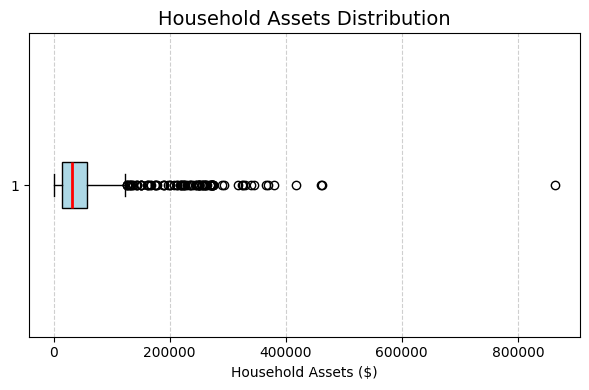

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['HH Assets'].dropna(),
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Household Assets Distribution', fontsize=14)
plt.xlabel('Household Assets ($)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
df_filtered = df[df['HH Assets'] <= 800000].copy()
print(f"originally: {len(df)}")
print(f"filtered: {len(df_filtered)}")


originally: 1740
filtered: 1716


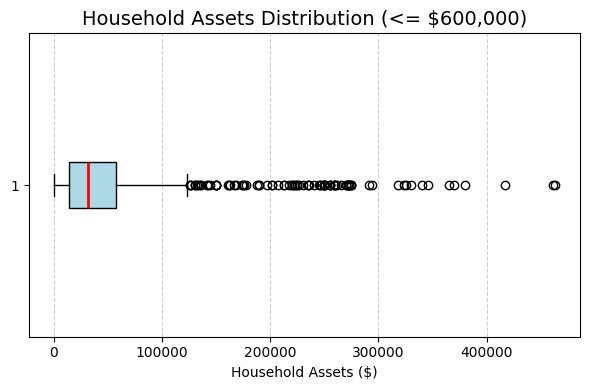

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df_filtered['HH Assets'].dropna(),
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Household Assets Distribution (<= $600,000)', fontsize=14)
plt.xlabel('Household Assets ($)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
df_filtered = df[(df['Age'] >= 18) & (df['HH Assets'] <= 600000)].copy()

print(f"originally: {len(df)}")
print(f"filtered: {len(df_filtered)}")


originally: 1740
filtered: 1614


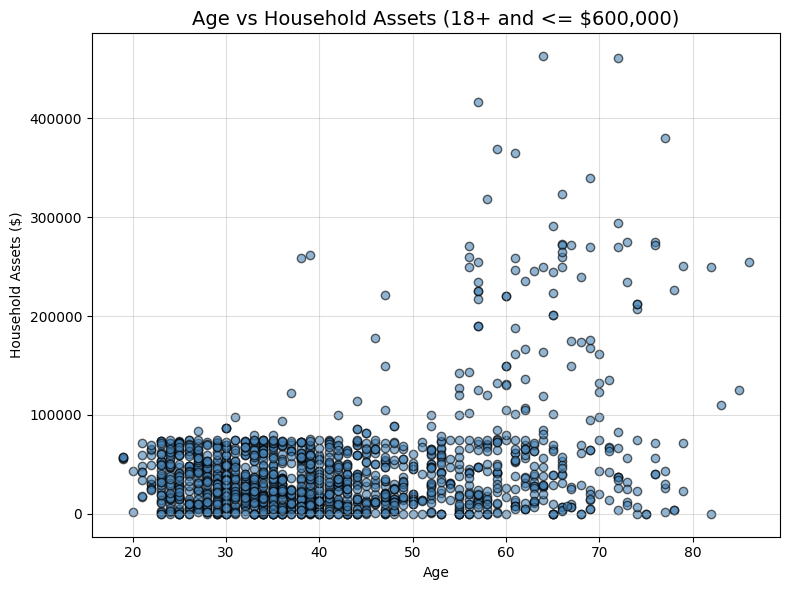

In [ ]:
df_scatter = df_filtered[['Age', 'HH Assets']].dropna()

plt.figure(figsize=(8,6))
plt.scatter(df_scatter['Age'], df_scatter['HH Assets'],
            alpha=0.6, color='steelblue', edgecolor='black')

plt.title('Age vs Household Assets (18+ and <= $600,000)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Household Assets ($)')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


#**Team Member 2: Pavlo Mysak**

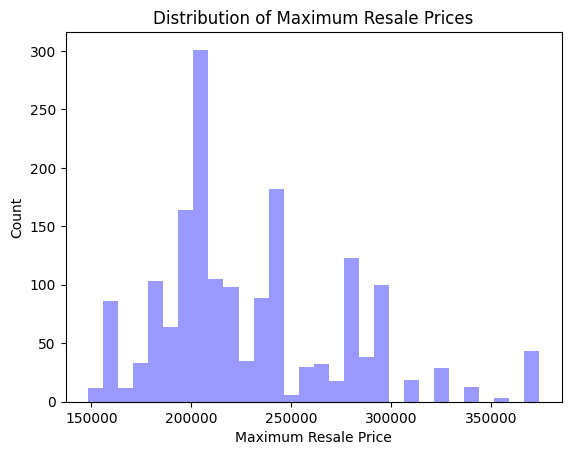

Mean: 229692.85    Median: 213319.00    Min:148438.0    Max: 374062.0   Stdev: 47280.93


In [ ]:
plt.hist(df["Property Maximum Resale Price"], color="blue", alpha = 0.4, bins=30)

plt.title("Distribution of Maximum Resale Prices")
plt.xlabel("Maximum Resale Price")
plt.ylabel("Count")
plt.show()

print(f"Mean: {df["Property Maximum Resale Price"].mean():.2f}    Median: {df["Property Maximum Resale Price"].median():.2f}    Min:{df["Property Maximum Resale Price"].min()}    Max: {df["Property Maximum Resale Price"].max()}   Stdev: {df["Property Maximum Resale Price"].std():.2f}")

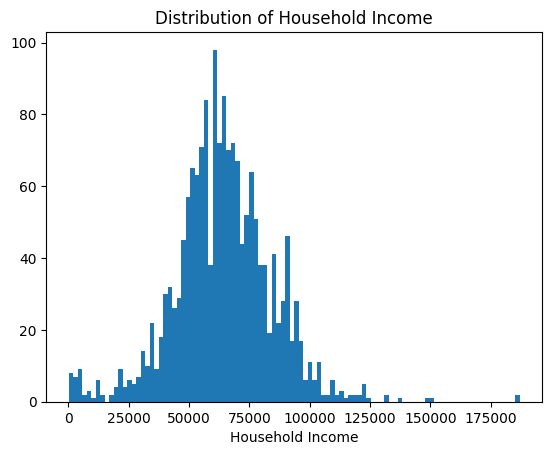

In [ ]:
hh_inc = pd.to_numeric(df["HH Income"], errors="coerce")

plt.hist(hh_inc[hh_inc<200000], bins = 100)
plt.title("Distribution of Household Income")
plt.xlabel("Household Income")
plt.show()

del hh_inc

[]

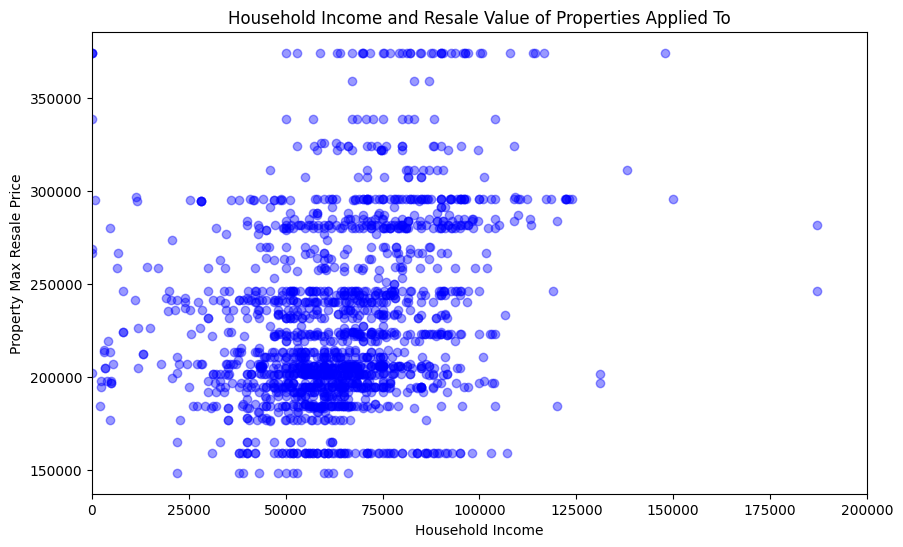

In [ ]:
# Visualize relationship between household income and resale value of home applied to
plt.figure(figsize=(10,6))
plt.scatter(pd.to_numeric(df["HH Income"], errors="coerce"),
            df["Property Maximum Resale Price"],
            color = "blue", alpha=0.4)

plt.xlabel("Household Income")
plt.ylabel("Property Max Resale Price")
plt.title("Household Income and Resale Value of Properties Applied To")
plt.xlim((0, 200000))
plt.plot()


[]

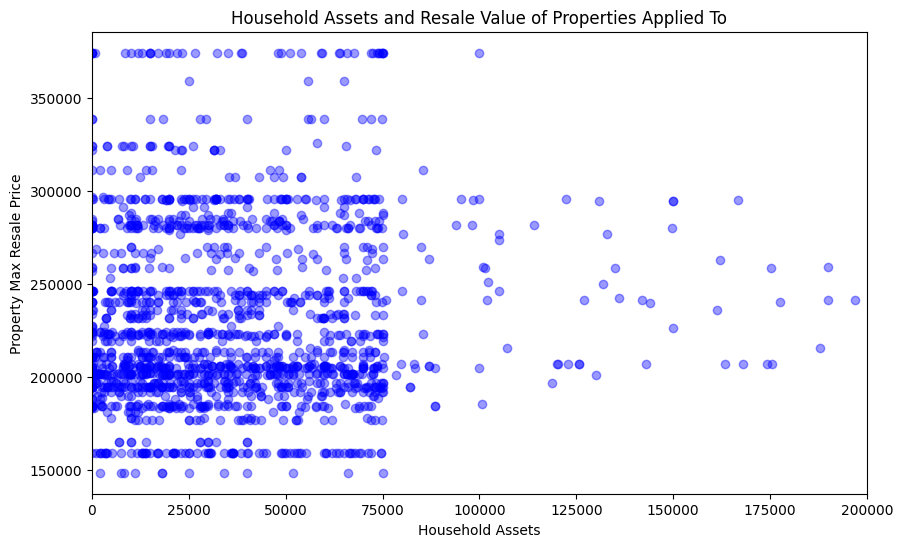

In [ ]:
# Visualize relationship between household income and resale value of home applied to

plt.figure(figsize=(10,6))
plt.scatter(pd.to_numeric(df["HH Assets"], errors="coerce"),
            df["Property Maximum Resale Price"],
            color = "blue", alpha=0.4)

plt.xlabel("Household Assets")
plt.ylabel("Property Max Resale Price")
plt.title("Household Assets and Resale Value of Properties Applied To")
plt.xlim((0, 200000))
plt.plot()

# What's with this cutoff at $75k here?

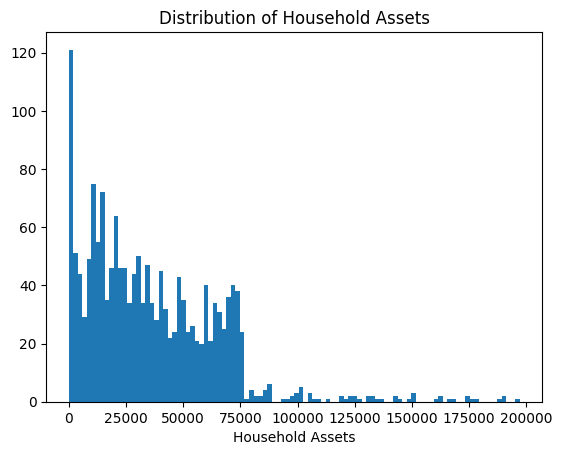

In [ ]:
# What does the cutoff look like in univariate?
hh_asts = pd.to_numeric(df["HH Assets"], errors="coerce")

plt.hist(hh_asts[hh_asts<200000], bins = 100)
plt.title("Distribution of Household Assets")
plt.xlabel("Household Assets")
plt.show()

del hh_asts

#**Team Member 3: SHRAVANI MASKAR**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving merged_resale_data_cleaned.csv to merged_resale_data_cleaned.csv


In [ ]:
import pandas as pd
df = pd.read_csv('merged_resale_data_cleaned.csv')

Descriptive statistics for Days on Market and Maximum Resale Price:
       Days_On_Market  Maximum Resale Price Numeric
count      135.000000                    135.000000
mean       150.437037                 229733.911111
std        113.500122                  41320.388362
min       -188.000000                 148438.000000
25%         97.500000                 193979.000000
50%        116.000000                 233433.000000
75%        191.000000                 257100.000000
max        821.000000                 374062.000000


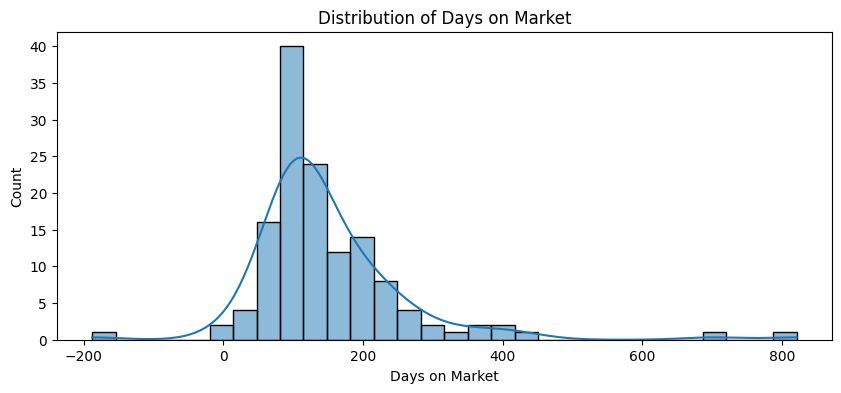

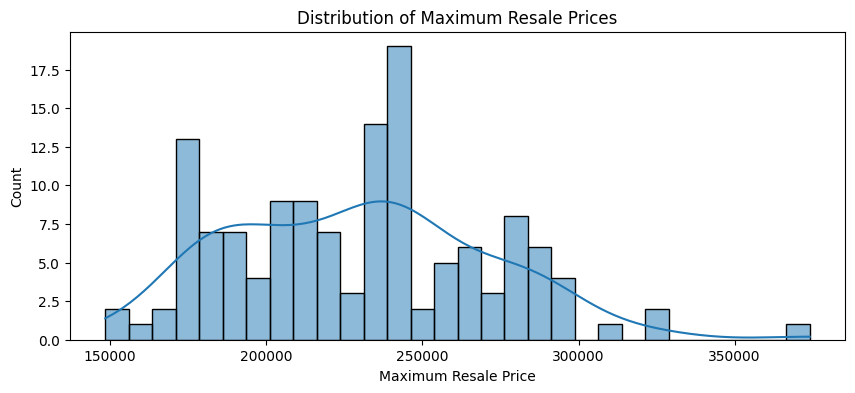

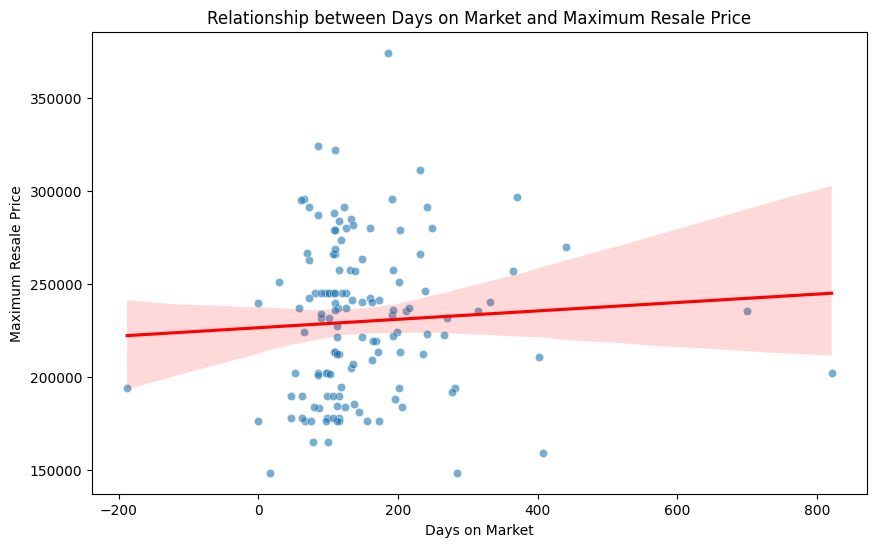

Correlation between Days on Market and Maximum Resale Price: 0.06


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert relevant columns to datetime, errors='coerce' handles invalid parsing safely
df['Transaction Start Date'] = pd.to_datetime(df['Transaction Start Date'], errors='coerce')
df['Closing Date'] = pd.to_datetime(df['Closing Date'], errors='coerce')

# Calculate Days on Market
df['Days_On_Market'] = (df['Closing Date'] - df['Transaction Start Date']).dt.days

# Convert Maximum Resale Price to numeric (adjust the column name if needed)
price_col = 'Maximum Resale Price Numeric'  # Replace with your actual column name if different
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

# Filter data to remove rows with missing Days on Market or Price
eda_df = df.dropna(subset=['Days_On_Market', price_col])

# Show descriptive statistics
print("Descriptive statistics for Days on Market and Maximum Resale Price:")
print(eda_df[['Days_On_Market', price_col]].describe())

# Plot distribution of Days on Market
plt.figure(figsize=(10, 4))
sns.histplot(eda_df['Days_On_Market'], bins=30, kde=True)
plt.title('Distribution of Days on Market')
plt.xlabel('Days on Market')
plt.ylabel('Count')
plt.show()

# Plot distribution of Maximum Resale Prices
plt.figure(figsize=(10, 4))
sns.histplot(eda_df[price_col], bins=30, kde=True)
plt.title('Distribution of Maximum Resale Prices')
plt.xlabel('Maximum Resale Price')
plt.ylabel('Count')
plt.show()

# Scatter plot + regression line: Resale Price vs Days on Market
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_df, x='Days_On_Market', y=price_col, alpha=0.6)
sns.regplot(data=eda_df, x='Days_On_Market', y=price_col, scatter=False, color='red')
plt.title('Relationship between Days on Market and Maximum Resale Price')
plt.xlabel('Days on Market')
plt.ylabel('Maximum Resale Price')
plt.show()

# Calculate and print correlation coefficient
correlation = eda_df[['Days_On_Market', price_col]].corr().iloc[0, 1]
print(f"Correlation between Days on Market and Maximum Resale Price: {correlation:.2f}")

#**Team Member 4: Brendan McManus**

In [ ]:
from os import rename
# defines cols and alias for charts
race_cols = [
    'dummy_asian', 'dummy_black_african_american',
    'dummy_native_american_alaskan_native',
    'dummy_white', 'dummy_white_MENA', 'dummy_hispanic',
    'dummy_choose_not_to_answer', 'dummy_unknown',
]

map_names_for_plots ={
    'dummy_asian': 'Asian',
    'dummy_black_african_american': 'Black / African American',
    'dummy_native_american_alaskan_native': 'Native American / Alaskan Native',
    'dummy_white': 'White',
    'dummy_white_MENA': 'White (MENA)',
    'dummy_hispanic': 'Hispanic',
    'dummy_choose_not_to_answer': 'Prefer Not to Answer',
    'dummy_unknown': 'Unknown'
}

race_counts = df[race_cols].sum().sort_values(ascending=False) # sums of dummy cols

mixed_race = df[df['is_mixed_race'] == 1][race_cols].sum() # sum of bool mixed_race col for applicants that are mixed race
non_mixed_race = df[df['is_mixed_race'] == 0][race_cols].sum() # sum of bool mixed_race col for applicants that are not mixed race

counts = (
    pd.DataFrame(
        {
            'Mixed Race': mixed_race,
            'Single Race': non_mixed_race
        }
    ))

counts.rename(index=map_names_for_plots, inplace=True)

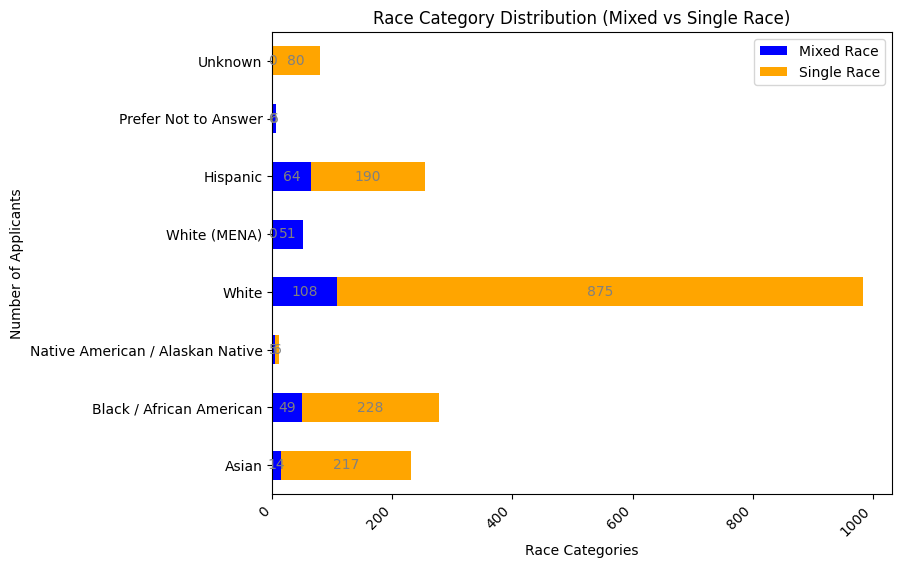

In [ ]:
ax = (
    counts.plot(
        kind='barh',
        stacked=True,
        figsize=(8,6),
        color=['blue', 'orange']
    ))
plt.title('Race Category Distribution (Mixed vs Single Race)')
plt.xlabel('Race Categories')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
  ax.bar_label(container, label_type='center', fontsize=10, color='grey')

plt.show()

